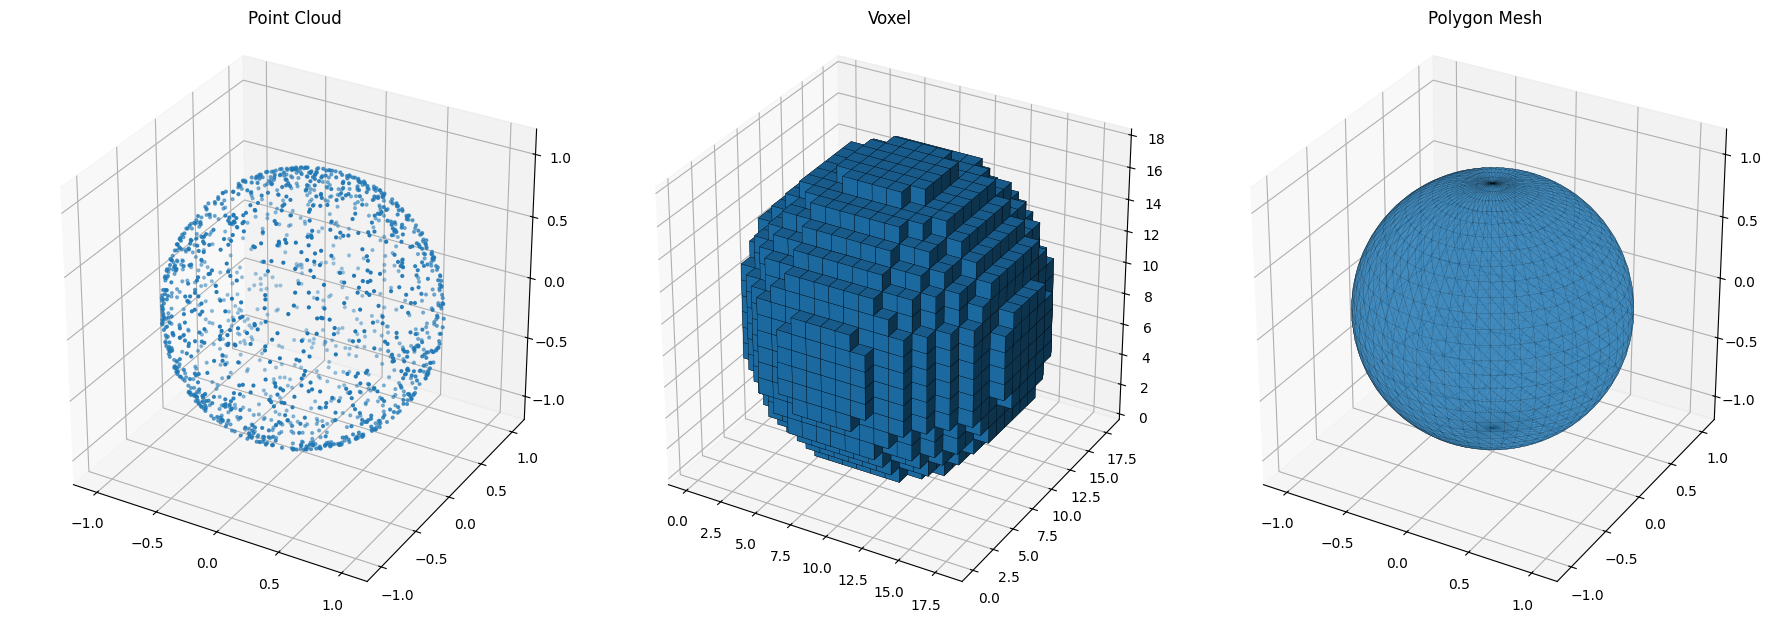

Bán kính hình cầu: 1.0
Số điểm point cloud: 1500
Kích thước lưới voxel: (18, 18, 18)
Số voxel được chọn: 1176
Số đỉnh mesh: 1800
Số mặt tam giác: 3422
Kiểm tra hoàn tất: dữ liệu 3D đã được tạo đúng.


In [ ]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: BIỂU DIỄN DỮ LIỆU 3D
# Chương/Mục liên quan: Chương 3, Mục 3.3.4
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa ba cách biểu diễn dữ liệu 3D thường gặp:
#   1. Đám mây điểm
#   2. Voxel
#   3. Lưới đa giác
# - Giúp người học quan sát sự khác nhau giữa biểu diễn rời rạc bằng điểm,
#   biểu diễn theo ô lưới không gian và biểu diễn bằng các mặt đa giác.
# - Liên hệ phần code với nội dung lý thuyết về biểu diễn hình học 3D.

# Sau khi chạy code, người học cần:
# 1. Hiểu được cách một vật thể 3D có thể được biểu diễn theo nhiều dạng khác nhau.
# 2. Quan sát được sự khác nhau giữa point cloud, voxel và polygon mesh.
# 3. Biết thay đổi các tham số đầu vào để kiểm tra kết quả.

# Input:
# - Dữ liệu đầu vào: dữ liệu 3D hình cầu được sinh trực tiếp bằng công thức tham số.
# - Kiểu dữ liệu: tọa độ 3D.

# Output:
# - Biểu diễn point cloud của hình cầu.
# - Biểu diễn voxel của hình cầu.
# - Biểu diễn polygon mesh của hình cầu.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# 2. TẠO DỮ LIỆU ĐẦU VÀO
# ============================================================

# ------------------------------------------------------------
# Thiết lập tham số đầu vào
# ------------------------------------------------------------

# Bán kính hình cầu
R = 1.0

# Số điểm của point cloud
num_points = 1500

# Kích thước lưới voxel
grid_size = 18

# Số mẫu theo hai hướng tham số của mesh
num_u = 60
num_v = 30

# Ngưỡng chọn voxel gần bề mặt hình cầu
epsilon = 0.08


# ------------------------------------------------------------
# Tạo lưới tham số của hình cầu
# ------------------------------------------------------------

# Đây là bước tương ứng với biểu diễn tham số của bề mặt hình cầu:
#
# x = R.cos(u).sin(v)
# y = R.sin(u).sin(v)
# z = R.cos(v)

u = np.linspace(0, 2 * np.pi, num_u)
v = np.linspace(0, np.pi, num_v)

x = R * np.outer(np.cos(u), np.sin(v))
y = R * np.outer(np.sin(u), np.sin(v))
z = R * np.outer(np.ones_like(u), np.cos(v))


# ============================================================
# 3. BIỂU DIỄN POINT CLOUD
# ============================================================

# Point cloud biểu diễn vật thể bằng tập các điểm 3D rời rạc.

phi = np.random.uniform(0, 2 * np.pi, num_points)
costheta = np.random.uniform(-1, 1, num_points)
theta = np.arccos(costheta)

px = R * np.sin(theta) * np.cos(phi)
py = R * np.sin(theta) * np.sin(phi)
pz = R * np.cos(theta)


# ============================================================
# 4. BIỂU DIỄN VOXEL
# ============================================================

# Voxel chia không gian 3D thành các ô lưới nhỏ.

gx, gy, gz = np.indices((grid_size, grid_size, grid_size))

# Chuẩn hóa tọa độ voxel về khoảng [-R, R]

gx_n = (gx / (grid_size - 1)) * 2 * R - R
gy_n = (gy / (grid_size - 1)) * 2 * R - R
gz_n = (gz / (grid_size - 1)) * 2 * R - R

# Tính khoảng cách từ voxel tới tâm hình cầu

radius = np.sqrt(gx_n**2 + gy_n**2 + gz_n**2)

# Điều kiện chọn voxel gần bề mặt hình cầu:
#
# |r - R| < epsilon

voxels = np.abs(radius - R) < epsilon


# ============================================================
# 5. BIỂU DIỄN POLYGON MESH
# ============================================================

# Polygon mesh biểu diễn bề mặt bằng các tam giác nhỏ.

vertices = np.stack([x.ravel(), y.ravel(), z.ravel()], axis=1)

faces = []

rows, cols = x.shape

for i in range(rows - 1):
    for j in range(cols - 1):

        p1 = i * cols + j
        p2 = (i + 1) * cols + j
        p3 = (i + 1) * cols + (j + 1)
        p4 = i * cols + (j + 1)

        faces.append([p1, p2, p3])
        faces.append([p1, p3, p4])

mesh_faces = vertices[np.array(faces)]


# ============================================================
# 6. HÀM HỖ TRỢ HIỂN THỊ 3D
# ============================================================

def set_axes_equal(ax, radius_limit):

    ax.set_xlim(-radius_limit, radius_limit)
    ax.set_ylim(-radius_limit, radius_limit)
    ax.set_zlim(-radius_limit, radius_limit)

    ax.set_box_aspect([1, 1, 1])


# ============================================================
# 7. HIỂN THỊ KẾT QUẢ
# ============================================================

fig = plt.figure(figsize=(18, 6))

# ------------------------------------------------------------
# Point Cloud
# ------------------------------------------------------------

ax1 = fig.add_subplot(131, projection="3d")

ax1.scatter(px, py, pz, s=4)

ax1.set_title("Point Cloud")

set_axes_equal(ax1, 1.2 * R)


# ------------------------------------------------------------
# Voxel
# ------------------------------------------------------------

ax2 = fig.add_subplot(132, projection="3d")

ax2.voxels(
    voxels,
    edgecolor="k",
    linewidth=0.2
)

ax2.set_title("Voxel")

ax2.set_box_aspect([1, 1, 1])


# ------------------------------------------------------------
# Polygon Mesh
# ------------------------------------------------------------

ax3 = fig.add_subplot(133, projection="3d")

mesh_collection = Poly3DCollection(
    mesh_faces,
    alpha=0.6,
    edgecolor="k",
    linewidth=0.1
)

ax3.add_collection3d(mesh_collection)

ax3.set_title("Polygon Mesh")

set_axes_equal(ax3, 1.2 * R)

plt.tight_layout()
plt.show()


# ============================================================
# 8. KIỂM TRA KẾT QUẢ
# ============================================================

print("Bán kính hình cầu:", R)

print("Số điểm point cloud:", len(px))

print("Kích thước lưới voxel:", voxels.shape)

print("Số voxel được chọn:", np.sum(voxels))

print("Số đỉnh mesh:", len(vertices))

print("Số mặt tam giác:", len(faces))

assert len(px) == num_points

assert voxels.shape == (grid_size, grid_size, grid_size)

assert len(vertices) == x.size

assert len(faces) == 2 * (rows - 1) * (cols - 1)

print("Kiểm tra hoàn tất: dữ liệu 3D đã được tạo đúng.")


# ============================================================
# 9. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi R để quan sát kích thước hình cầu thay đổi.
# 2. Thay đổi num_points để quan sát point cloud thưa hoặc dày hơn.
# 3. Thay đổi grid_size để quan sát độ phân giải của voxel.
# 4. Thay đổi num_u và num_v để quan sát độ mịn của polygon mesh.
# 5. Thay đổi epsilon để quan sát độ dày của lớp voxel quanh bề mặt.